In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torchvision.utils as vutils
from torchvision import datasets, transforms
import torch
import torch.nn as nn
DEVICE = torch.device("cuda")
import wandb
from sklearn.manifold import TSNE
import seaborn as sns
import torch.nn.functional as F
import math



# Implementation Procedure

Here's how we are going to proceed:

1. Import data. 
2. Create a UNET architecture with skip connection
3. Create the transition kernel.
4. Implement the training loop.
5. Implement the sampling procedure
## Transition Kernel

- Add noise to go to time t by:  
$x_t =  \sqrt{\bar{\alpha}_t} x_0 +  \sqrt{(1 - \bar{\alpha}_t)} n $  
``` x_t = sqrt_alpha_bar * x_0 + sqrt_one_minus_alpha_bar * noise```

## Training Process
- Get the $x_t$ then try to predict what noise has been added to $x_t$
- Minimize $\left| \epsilon_\theta(x_t, t) - \epsilon(t) \right|$

## Sampling Process
For sampling:
- Start at $t = T$
- Take one step forward by:
  - Making the diffusion diff_model predict the original image $\hat{x}$
  - Then add apropiet noise in size of $t-1$ 
- Continue taking steps forward until you hit $t = 0$

## Importing Data

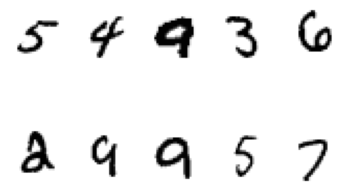

In [2]:
transform = transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize((0.1307,), (0.3081,))])

full_trainset = datasets.MNIST('MNIST_data/', download=True, train=True, transform=transform)
# Select a subset of the training data
indices = torch.randperm(len(full_trainset))[:800]
trainset = torch.utils.data.Subset(full_trainset, indices)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)


testset = datasets.MNIST('MNIST_data/', download=True, train=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=400, shuffle=True)



dataiter = iter(trainloader)
images, labels = next(dataiter)

figure = plt.figure()
num_of_images = 10
for index in range(1, num_of_images + 1):
    plt.subplot(2, 5, index)
    plt.axis('off')
    plt.imshow(images[index].numpy().squeeze(), cmap='gray_r')

## Creating Model

In [3]:


def sinusoidal_time_embedding(timesteps, embedding_dim):
    # timesteps: 1D tensor of shape (batch_size,)
    # embedding_dim: scalar
    half_dim = embedding_dim // 2
    embeddings = math.log(10000) / (half_dim - 1)
    embeddings = torch.exp(torch.arange(half_dim, device=timesteps.device) * -embeddings)
    embeddings = timesteps.float().unsqueeze(1) * embeddings.unsqueeze(0)
    embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
    if embedding_dim % 2 == 1:  # Zero pad if embedding_dim is odd
        embeddings = F.pad(embeddings, (0,1))
    return embeddings

class U_net(nn.Module):
    def __init__(self, code_dim=16, time_embedding_dim=64, num_classes=10, class_embedding_dim=64):
        super().__init__()
        self.code_dim = code_dim
        self.time_embedding_dim = time_embedding_dim
        self.num_classes = num_classes
        self.class_embedding_dim = class_embedding_dim

        if self.num_classes is not None:
            self.class_embedding = nn.Embedding(num_classes, class_embedding_dim)

        # Encoder
        # Conv1: 28x28x1 -> 28x28x4
        self.cnn_1 = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3, padding=1)
        self.pool_1 = nn.MaxPool2d(kernel_size=2, stride=2) # 28x28 -> 14x14

        # Conv2: 14x14x4 -> 14x14x16
        self.cnn_2 = nn.Conv2d(in_channels=4, out_channels=16, kernel_size=3, padding=1)
        self.pool_2 = nn.MaxPool2d(kernel_size=2, stride=2) # 14x14 -> 7x7

        # Conv3: 7x7x16 -> 7x7x64
        self.cnn_3 = nn.Conv2d(in_channels=16, out_channels=64, kernel_size=3, padding=1)

        # Conv4: 7x7x64 -> 4x4x128
        self.cnn_4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1) # 7x7 -> 4x4

        # Bottleneck
        self.flatten = nn.Flatten()
        # 128 * 4 * 4 = 2048
        bottleneck_features = 128 * 4 * 4
        self.linear_1 = nn.Linear(bottleneck_features, 512) # 2048 -> 512
        self.linear_2 = nn.Linear(512, code_dim)           # 512 -> 16 (final bottleneck dim)

        self.tr_linear_2 = nn.Linear(code_dim, 512)           # 16 -> 512
        self.tr_linear_1 = nn.Linear(512, 1536) # 512 -> 1536 (512 coming from before bottleneck b1

       
        # UpConvB1: 4x4x128 -> 7x7x64
        self.conv_trans_b1 = nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1) # 4x4 -> 7x7

        # 14x14x16
        self.conv_trans_1 = nn.ConvTranspose2d(in_channels=64, out_channels=16, kernel_size=2, stride=2, padding=1) # 7x7 -> 14x14
        # 14x14x(16+16)  
        self.cnn_up_1 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)

        # 14x14x32 -> 28x28x4
        self.conv_trans_2 = nn.ConvTranspose2d(in_channels=32, out_channels=4, kernel_size=2, stride=2)

        self.cnn_up_2 = nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3, padding=1)

        #28x28x8 -> 28x28x1
        self.final_conv = nn.Conv2d(in_channels=8, out_channels=1, kernel_size=1)

        self.non_linear = nn.LeakyReLU()

        # self.time_embed_base = nn.Sequential(
        #     nn.Linear(1, 64),
        #     nn.LeakyReLU(),
        #     nn.Linear(64, 64)
        # )

        
        self.time_proj_enc1 = nn.Linear(self.time_embedding_dim, 4)
        self.time_proj_enc2 = nn.Linear(self.time_embedding_dim, 16)
        self.time_proj_enc3 = nn.Linear(self.time_embedding_dim, 64)
        self.time_proj_enc4 = nn.Linear(self.time_embedding_dim, 128) # For cnn_4 output (128)

        self.time_proj_bottleneck1 = nn.Linear(self.time_embedding_dim, 512) # For linear_1 output 
        self.time_proj_bottleneck2 = nn.Linear(self.time_embedding_dim, code_dim)         # For linear_2 outp
        self.time_proj_tr_bottleneck1 = nn.Linear(self.time_embedding_dim, 512) # For tr_linear_2 out
        self.time_proj_tr_bottleneck2 = nn.Linear(self.time_embedding_dim, bottleneck_features) # For tr_linear_1 output

        # Time projection for the bottleneck transpose conv
        self.time_proj_dec_b1 = nn.Linear(self.time_embedding_dim, 64) # For conv_trans_b1 output (64)

        self.time_proj_dec1 = nn.Linear(self.time_embedding_dim, 32) # Matches output of cnn_up_1
        self.time_proj_dec2 = nn.Linear(self.time_embedding_dim, 8)  # Matches output of cnn_up_2

    def _apply_time_embedding(self, x, time_emb_proj):
        # Used for convolutional layers
        time_emb = time_emb_proj.reshape(time_emb_proj.shape[0], time_emb_proj.shape[1], 1, 1)
        # Expand to match spatial dimensions of x
        time_emb = time_emb.expand(-1, -1, x.shape[2], x.shape[3])
        return x + time_emb

    def forward(self, x, t=None, c=None):

        time_emb = sinusoidal_time_embedding(t, self.time_embedding_dim)
        time_emb = time_emb.to(x.device) # Ensure embedding is on the same device as x

        if c is not None and self.num_classes is not None:
            class_emb = self.class_embedding(c)
            class_emb = class_emb.to(x.device)
            combined_emb = time_emb + class_emb
        else:
            combined_emb = time_emb

        # Encoder
        x1 = self.cnn_1(x) # 4ch, 28x28
        t_emb_p1 = self.time_proj_enc1(combined_emb)
        x1 = self.non_linear(self._apply_time_embedding(x1, t_emb_p1))
        p1 = self.pool_1(x1) # 4ch, 14x14

        x2 = self.cnn_2(p1) # 16ch, 14x14
        t_emb_p2 = self.time_proj_enc2(combined_emb)
        x2 = self.non_linear(self._apply_time_embedding(x2, t_emb_p2))
        p2 = self.pool_2(x2) # 16ch, 7x7

        x3 = self.cnn_3(p2) # 64ch, 7x7
        t_emb_p3 = self.time_proj_enc3(combined_emb)
        x3 = self.non_linear(self._apply_time_embedding(x3, t_emb_p3))

        x4 = self.cnn_4(x3) # 128ch, 4x4
        t_emb_p4 = self.time_proj_enc4(combined_emb)
        x4 = self.non_linear(self._apply_time_embedding(x4, t_emb_p4))

        # Bottleneck
        flat = self.flatten(x4) # 2048 features

        b1 = self.linear_1(flat) # 512 
        t_emb_b1 = self.time_proj_bottleneck1(combined_emb)
        b1 = self.non_linear(b1 + t_emb_b1)  

        z = self.linear_2(b1) # code_dim 
        t_emb_z = self.time_proj_bottleneck2(combined_emb)
        z = self.non_linear(z + t_emb_z)  

        b_tr1 = self.tr_linear_2(z) # 512
        t_emb_tr_b1 = self.time_proj_tr_bottleneck1(combined_emb)
        b_tr1 = self.non_linear(b_tr1 + t_emb_tr_b1)  

        b_tr2 = torch.cat([ b1, self.tr_linear_1(b_tr1)], dim=1) # bottleneck_features (1536 + 512)
        t_emb_tr_b2 = self.time_proj_tr_bottleneck2(combined_emb)
        b_tr2 = self.non_linear(b_tr2 + t_emb_tr_b2)  

        # Reshape back to convolutional shape before transpose conv
        b_reshaped = b_tr2.view(b_tr2.shape[0], 128, 4, 4)

        b = self.conv_trans_b1(b_reshaped) # 64ch, 7x7
        t_emb_db1 = self.time_proj_dec_b1(combined_emb)
        b = self.non_linear(self._apply_time_embedding(b, t_emb_db1))

        # Decoder
        d1 = self.conv_trans_1(b) # 16ch, 14x14

        # print(d1.shape)
        d1 = torch.cat([d1, x2], dim=1) # 16+16=32ch, 14x14
        d1 = self.cnn_up_1(d1) # 32ch, 14x14
        t_emb_d1 = self.time_proj_dec1(combined_emb)
        d1 = self.non_linear(self._apply_time_embedding(d1, t_emb_d1))

        d2 = self.conv_trans_2(d1) # 4ch, 28x28

        d2 = torch.cat([d2, x1], dim=1) # 4+4=8ch, 28x28
        d2 = self.cnn_up_2(d2) # 8ch, 28x28
        t_emb_d2 = self.time_proj_dec2(combined_emb)
        d2 = self.non_linear(self._apply_time_embedding(d2, t_emb_d2))

        # Final Layer
        output = self.final_conv(d2) # 1ch, 28x28
        return output

## Transition Kernel

In [4]:
class DiffForward:
    """
    Simple forward diffusion that adds noise to an image based on timestep t.
    Following the formula: x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * eps
    """
    def __init__(self, total_timesteps=1000):
        self.alphas = torch.linspace(0.9999, 0.98, total_timesteps)
        self.alpha_bars = torch.cumprod(self.alphas, dim=0).to(DEVICE)
        self.total_timesteps = total_timesteps
        
    def forward(self, x_0, t):
        device = x_0.device
        noise = torch.randn_like(x_0).to(device)
        sqrt_alpha_bar = torch.sqrt(self.alpha_bars[t]).view(-1, 1, 1, 1).to(device)     # We to reshape it as to -1 for batch size, 1 for channels, and the rest for spatial dim
        sqrt_one_minus_alpha_bar = torch.sqrt(1 - self.alpha_bars[t]).view(-1, 1, 1, 1).to(device)
        x_t = sqrt_alpha_bar * x_0 + sqrt_one_minus_alpha_bar * noise
        return x_t, noise

## Sampling 

In [5]:
def sample_cfg_unconditional(diff_model, total_timesteps, diff_forward, device, num_samples=16, target_classes=None, guidance_scale=0.0):
    diff_model.eval()
    with torch.no_grad():
        x_t = torch.randn(num_samples, 1, 28, 28, device=device)
        alphas = diff_forward.alphas.to(device) # Ensure on correct device
        alpha_bars = diff_forward.alpha_bars.to(device) # Ensure on correct device
        
        intermediate_samples = []
        steps_to_save = [int(i) for i in np.linspace(0, total_timesteps - 1, num=8)]

        for t in reversed(range(total_timesteps)):
            t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)
            
            # Classifier-Free Guidance logic
            unconditional_epsilon = diff_model(x_t, t_tensor, c=None)
            
            if target_classes is not None and guidance_scale > 0.0:
                # Ensure target_classes are on the correct device
                current_target_classes = target_classes.to(device)
                if current_target_classes.shape[0] != num_samples:
                    # Basic handling if target_classes don't match num_samples (e.g. for visualization)
                    current_target_classes = current_target_classes[torch.arange(num_samples) % current_target_classes.shape[0]]
                conditional_epsilon = diff_model(x_t, t_tensor, c=current_target_classes)
                predicted_noise = unconditional_epsilon + guidance_scale * (conditional_epsilon - unconditional_epsilon)
            elif target_classes is not None: # Conditional prediction without guidance scaling
                current_target_classes = target_classes.to(device)
                if current_target_classes.shape[0] != num_samples:
                    current_target_classes = current_target_classes[torch.arange(num_samples) % current_target_classes.shape[0]]
                predicted_noise = diff_model(x_t, t_tensor, c=current_target_classes)
            else: # Unconditional prediction
                predicted_noise = unconditional_epsilon
            
            coef1 = 1 / torch.sqrt(alphas[t])
            coef2 = (1 - alphas[t]) / torch.sqrt(1 - alpha_bars[t])
            x_0_pred = coef1 * (x_t - coef2 * predicted_noise)
            
            if t > 0:
                sigma_val = torch.sqrt(1 - alphas[t])
                noise_val = torch.randn_like(x_t)
                x_t = x_0_pred + sigma_val * noise_val
            else:
                x_t = x_0_pred
                
            if t in steps_to_save:
                intermediate_samples.append(x_t.cpu().clone())

    return x_t.cpu(), intermediate_samples

## Binding Pieces

In [6]:
epochs = 600
total_timesteps = 2000
batch_size = 64
learning_rate = 0.001
# Ensure num_classes is set for the conditional model, and specify embedding dimensions for clarity
diff_model = U_net(code_dim=128, num_classes=10, time_embedding_dim=64, class_embedding_dim=64).to(DEVICE)
optimizer = torch.optim.Adam(diff_model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

diff_forward = DiffForward(total_timesteps=total_timesteps)

In [7]:
# # # Best model will be loaded after training loop based on test performance
# diff_model_save_path = "unet_diff_mnist.pth"
# state_dict = torch.load(diff_model_save_path)
# diff_model.load_state_dict(state_dict)

### Main trainin loop

Epoch [15/600], Average Training Loss: 0.2274


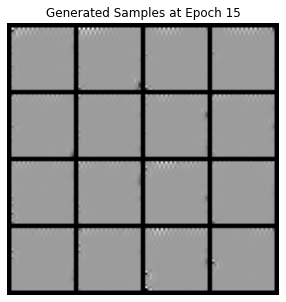

Epoch [30/600], Average Training Loss: 0.1438


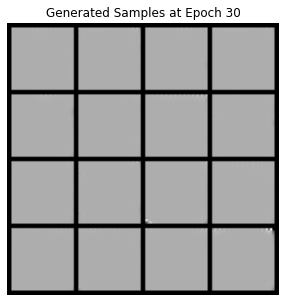

Epoch [45/600], Average Training Loss: 0.1298


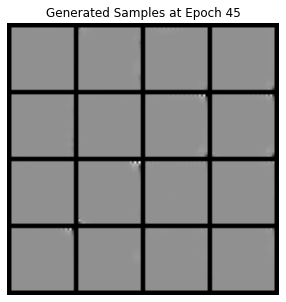

Epoch [60/600], Average Training Loss: 0.1102


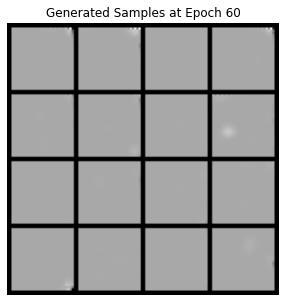

Epoch [75/600], Average Training Loss: 0.0991


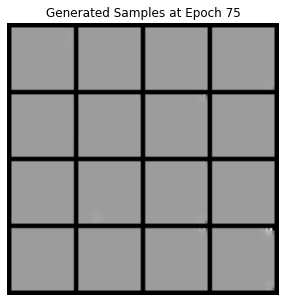

Epoch [90/600], Average Training Loss: 0.1160


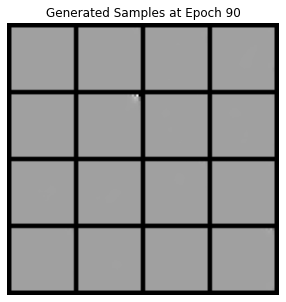

Epoch [105/600], Average Training Loss: 0.0926


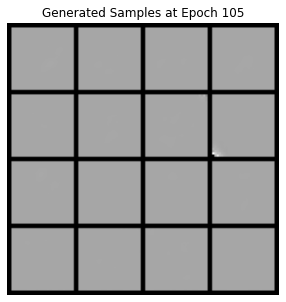

Epoch [120/600], Average Training Loss: 0.0928


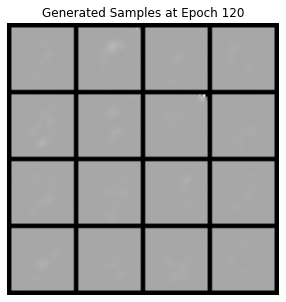

Epoch [135/600], Average Training Loss: 0.0916


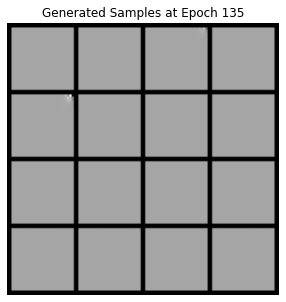

Epoch [150/600], Average Training Loss: 0.0953


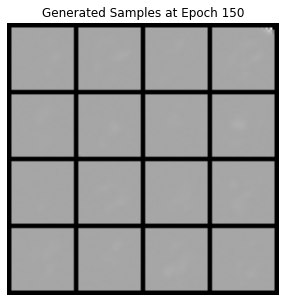

Epoch [165/600], Average Training Loss: 0.0938


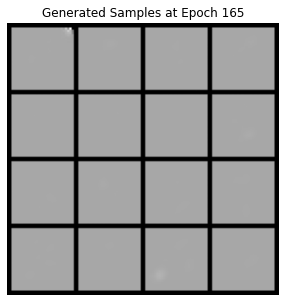

Epoch [180/600], Average Training Loss: 0.0874


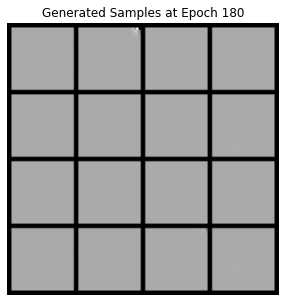

Epoch [195/600], Average Training Loss: 0.1003


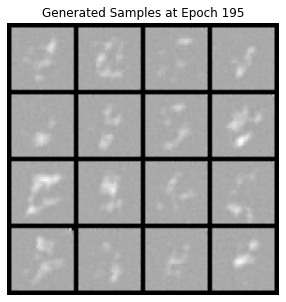

Epoch [210/600], Average Training Loss: 0.0830


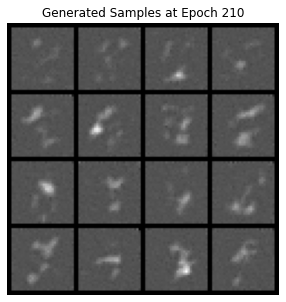

Epoch [225/600], Average Training Loss: 0.0905


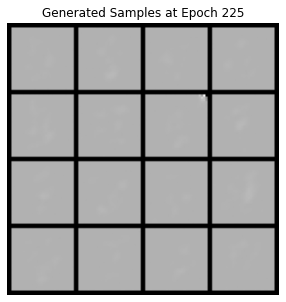

Epoch [240/600], Average Training Loss: 0.0891


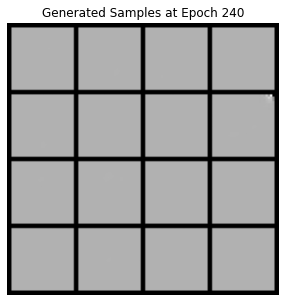

Epoch [255/600], Average Training Loss: 0.0933


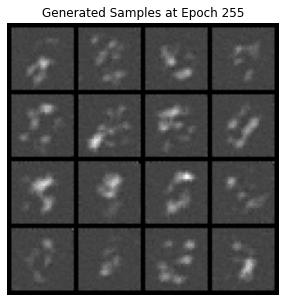

Epoch [270/600], Average Training Loss: 0.0783


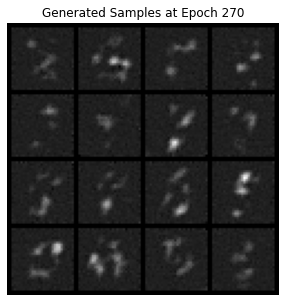

Epoch [285/600], Average Training Loss: 0.0795


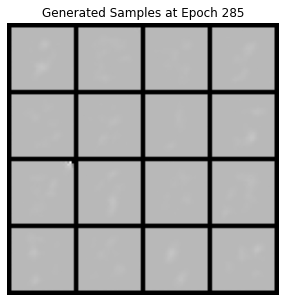

Epoch [300/600], Average Training Loss: 0.0763


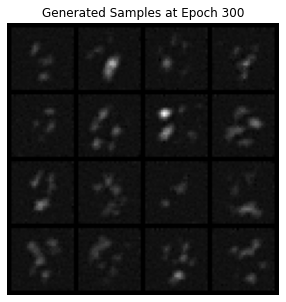

Epoch [315/600], Average Training Loss: 0.0872


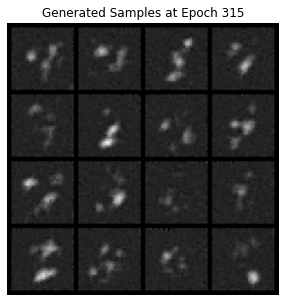

Epoch [330/600], Average Training Loss: 0.0863


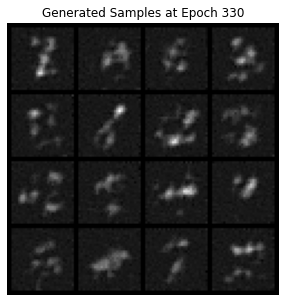

Epoch [345/600], Average Training Loss: 0.0709


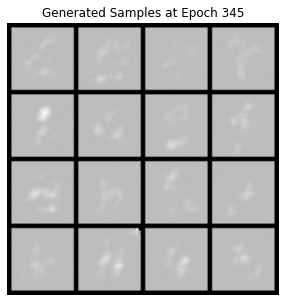

Epoch [360/600], Average Training Loss: 0.0764


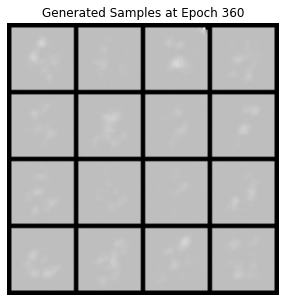

Epoch [375/600], Average Training Loss: 0.0835


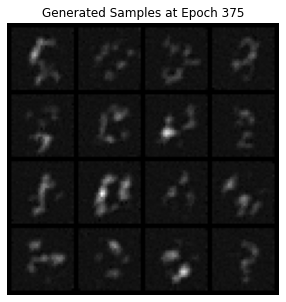

Epoch [390/600], Average Training Loss: 0.0794


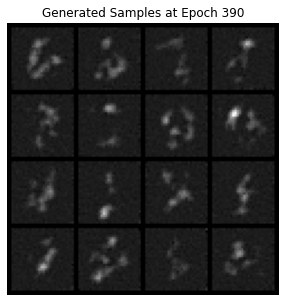

Epoch [405/600], Average Training Loss: 0.0709


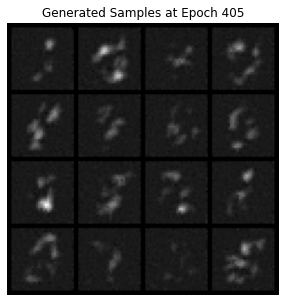

Epoch [420/600], Average Training Loss: 0.0825


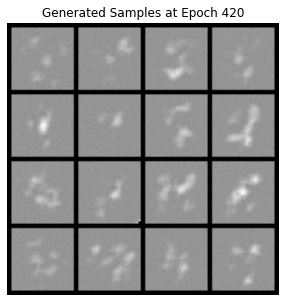

Epoch [435/600], Average Training Loss: 0.0702


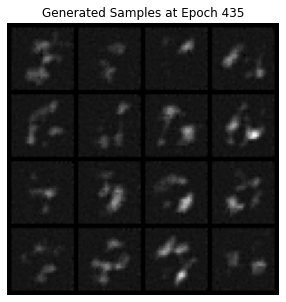

Epoch [450/600], Average Training Loss: 0.0757


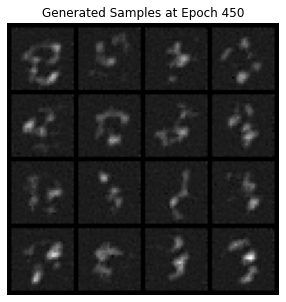

Epoch [465/600], Average Training Loss: 0.0746


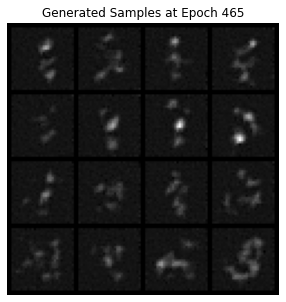

Epoch [480/600], Average Training Loss: 0.0797


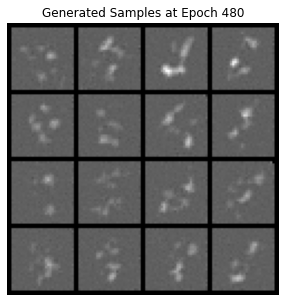

Epoch [495/600], Average Training Loss: 0.0845


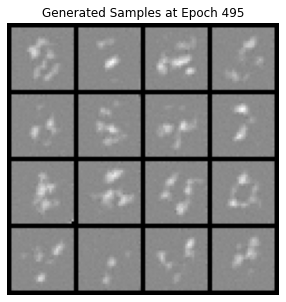

Epoch [510/600], Average Training Loss: 0.0684


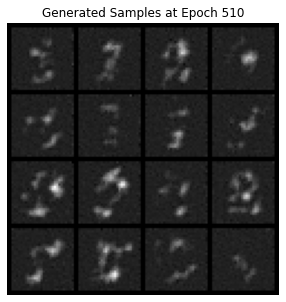

Epoch [525/600], Average Training Loss: 0.0785


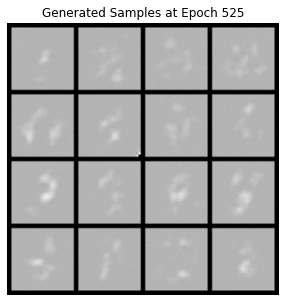

Epoch [540/600], Average Training Loss: 0.0863


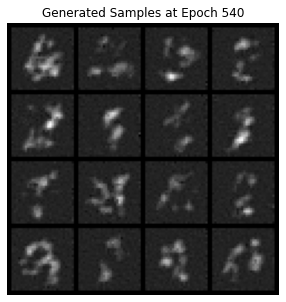

Epoch [555/600], Average Training Loss: 0.0728


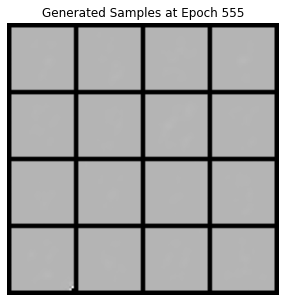

Epoch [570/600], Average Training Loss: 0.0675


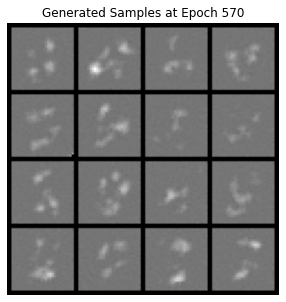

Epoch [585/600], Average Training Loss: 0.0862


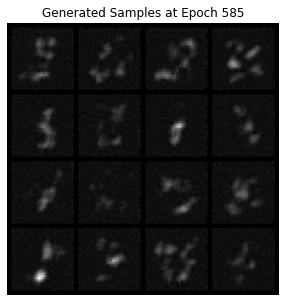

Epoch [600/600], Average Training Loss: 0.0657


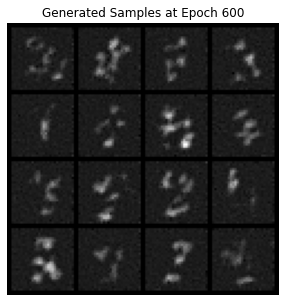

diff_model saved to unet_diff_mnist.pth


In [8]:



for epoch in range(0 ,  epochs):
    diff_model.train() 
    
    if epoch == 60:
        optimizer = torch.optim.Adam(diff_model.parameters(), lr=learning_rate / 10)

    
    epoch_loss = 0.0
    num_batches = 0
    for x_batch, _ in trainloader:
        x_batch = x_batch.to(DEVICE)
        optimizer.zero_grad()
        t = torch.randint(0, total_timesteps, (x_batch.shape[0],)).to(DEVICE)
        # We go to time step t:
        x_noisy_t, noise = diff_forward.forward(x_batch, t)
        # Model tries to predict the noise:
        added_noise = diff_model(x_noisy_t, t.float())
        loss = criterion(added_noise, noise)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        num_batches += 1
        
    diff_model.eval()

    
    if (epoch + 1) % 15 == 0:

        avg_epoch_loss = epoch_loss / num_batches
        print(f"Epoch [{epoch+1}/{epochs}], Average Training Loss: {avg_epoch_loss:.4f}")
        with torch.no_grad():
            # Use sample_cfg_unconditional for unconditional sampling visualization
            samples, _ = sample_cfg_unconditional(diff_model, total_timesteps, diff_forward, DEVICE, num_samples=16, target_classes=None, guidance_scale=0.0)

        grid = vutils.make_grid(samples, nrow=4, normalize=True, padding=2)        
        plt.figure(figsize=(10, 5))
        plt.axis('off')
        plt.title(f"Generated Samples at Epoch {epoch+1}")
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
        plt.show()
        
        diff_model.train()

diff_model_save_path = "unet_diff_mnist.pth"
torch.save(diff_model.state_dict(), diff_model_save_path)
print(f"diff_model saved to {diff_model_save_path}")



## Vizualization

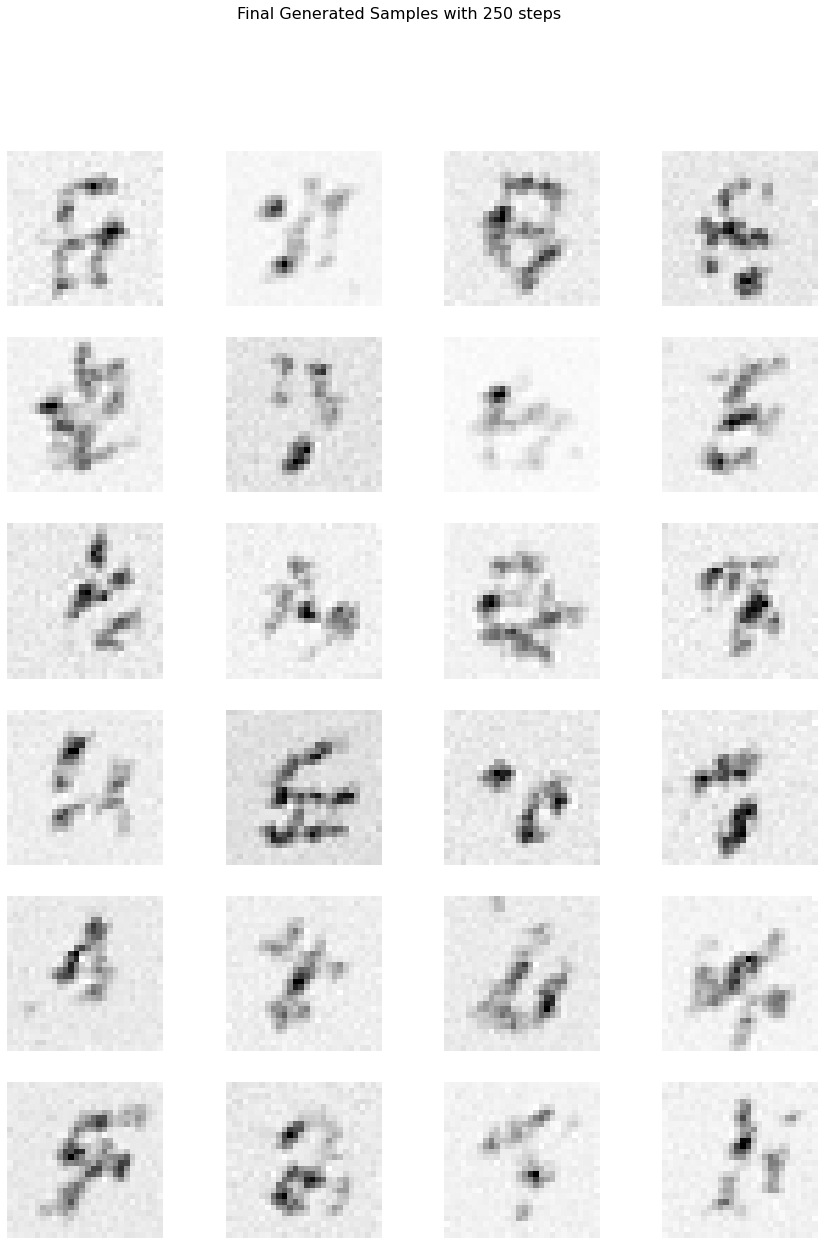

In [ ]:
# Generate and visualize samples using classifier guidance
print(f"Generating {num_samples_vis_guided} samples for visualization with guidance scale {guidance_scale_vis}...")
final_samples_guided, intermediates_guided = sample(
    diff_model=unconditional_unet, # Use the unconditionally trained U-Net
    classifier_model=model_lenet, # Use the LeNet classifier
    total_timesteps=guided_total_timesteps,
    diff_forward=guided_diff_forward,
    device=DEVICE,
    target_classes=target_classes_vis, # Target classes for visualization
    guidance_scale=guidance_scale_vis, # Guidance scale for visualization
    num_samples=num_samples_vis_guided,
    batch_size=8 # Smaller batch size for visualization if needed, adjust based on memory
)
print("Guided sample generation for visualization complete.")

# Plot the final guided samples
# final_samples_guided is already a numpy array from the sample function
grid_rows = (num_samples_vis_guided + 3) // 4 # Adjust grid based on num_samples_vis_guided
grid_cols = 4
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(12, grid_rows * 3)) 
fig.suptitle(f"Final Classifier-Guided Samples (Scale: {guidance_scale_vis})", fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < num_samples_vis_guided:
        img = final_samples_guided[i].squeeze()
        ax.imshow(img, cmap='gray_r')
        ax.set_title(f"Target: {target_classes_vis[i].item()}")
    ax.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

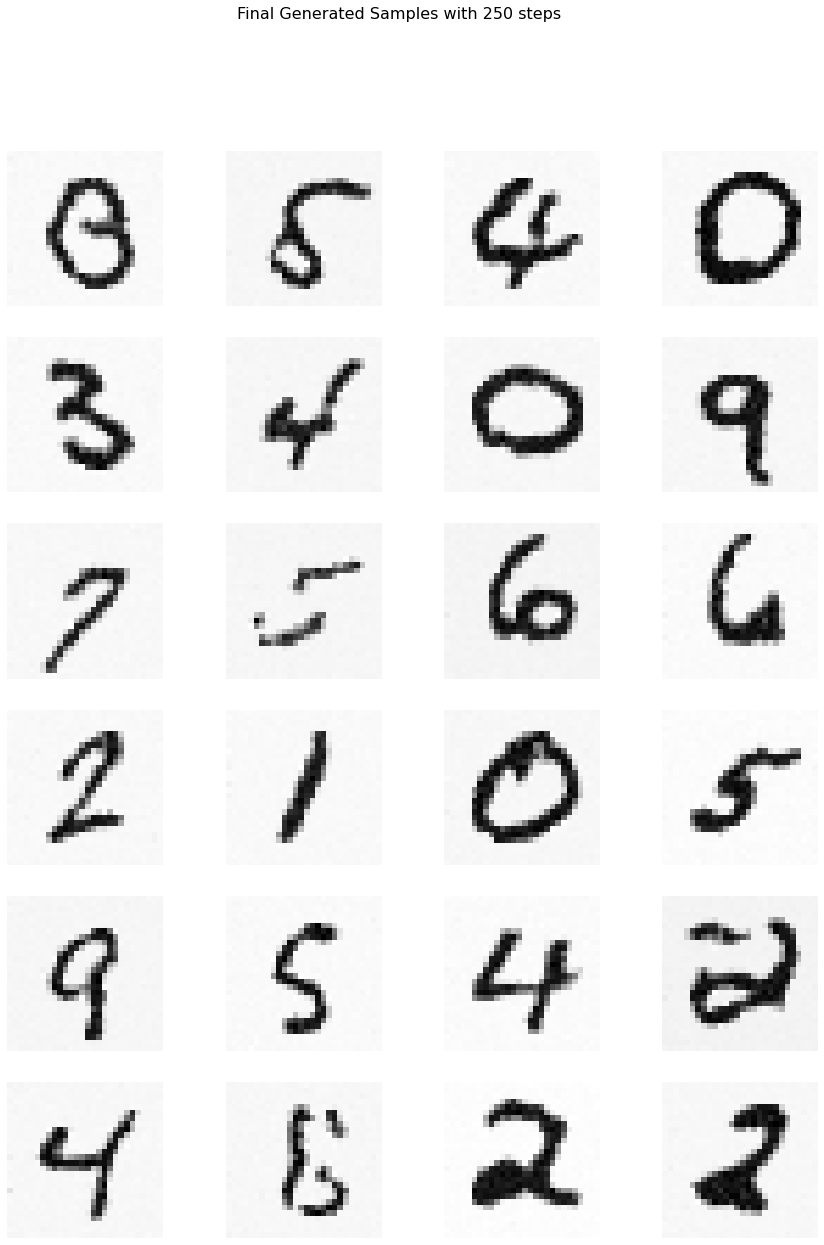

In [ ]:
# num_intermediate_digits = 10
# final_samples, intermediates = sample(diff_model, total_timesteps, diff_forward, DEVICE, num_samples=24)
# 
# final_samples_np = final_samples.cpu().numpy()
# grid_rows = 6
# grid_cols = 4 
# fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(15, 20)) 
# fig.suptitle("Final Generated Samples with 250 steps", fontsize=16)
# 
# for i, ax in enumerate(axes.flat):
#     img = final_samples_np[i].squeeze() 
#     ax.imshow(img, cmap='gray_r')
#     ax.axis('off')
#     
# plt.show()

In [ ]:
# Plot intermediate samples from classifier-guided generation
num_samples_to_show_guided = 10 # Show intermediates for the first 10 samples generated for visualization
if 'intermediates_guided' in globals() and len(intermediates_guided) > 0:
    num_timesteps_saved_guided = len(intermediates_guided)
    actual_samples_to_show = min(num_samples_to_show_guided, intermediates_guided[0].shape[0])

    fig, axes = plt.subplots(actual_samples_to_show, num_timesteps_saved_guided, 
                            figsize=(num_timesteps_saved_guided * 2, actual_samples_to_show * 2))
    fig.suptitle(f"Intermediate Classifier-Guided Samples (Scale: {guidance_scale_vis})", fontsize=16)

    saved_timesteps_values = [int(i) for i in np.linspace(0, guided_total_timesteps - 1, num=num_timesteps_saved_guided)]

    for t_plot_idx in range(num_timesteps_saved_guided):
        actual_t_value_index = num_timesteps_saved_guided - 1 - t_plot_idx
        axes[0, t_plot_idx].set_title(f"t={saved_timesteps_values[actual_t_value_index]}")

    for sample_idx in range(actual_samples_to_show):
        for t_plot_idx in range(num_timesteps_saved_guided):
            intermediate_idx_to_fetch = num_timesteps_saved_guided - 1 - t_plot_idx
            img_tensor = intermediates_guided[intermediate_idx_to_fetch][sample_idx]
            img = img_tensor.squeeze().numpy()
            axes[sample_idx, t_plot_idx].imshow(img, cmap='gray_r')
            axes[sample_idx, t_plot_idx].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
else:
    print("No intermediate guided samples to display or 'intermediates_guided' not found.")

NameError: name 'intermediates' is not defined

Epoch [15/1000], Average Training Loss: 0.0915


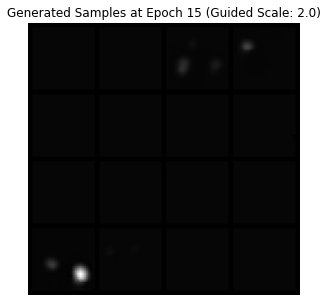

Epoch [30/1000], Average Training Loss: 0.0943


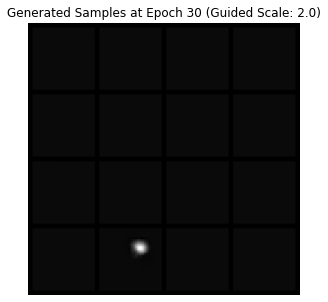

Epoch [45/1000], Average Training Loss: 0.0768


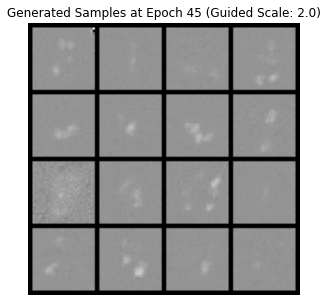

Epoch [60/1000], Average Training Loss: 0.0805


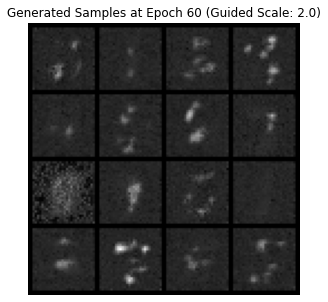

Epoch [75/1000], Average Training Loss: 0.0821


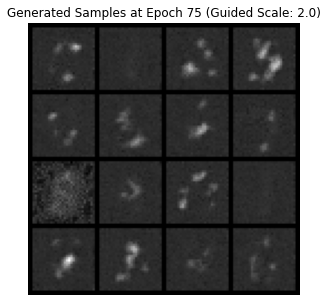

Epoch [90/1000], Average Training Loss: 0.0915


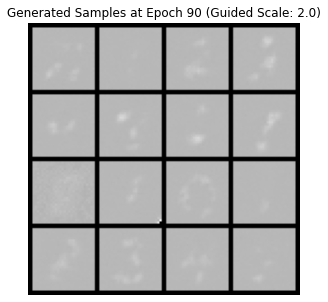

Epoch [105/1000], Average Training Loss: 0.0747


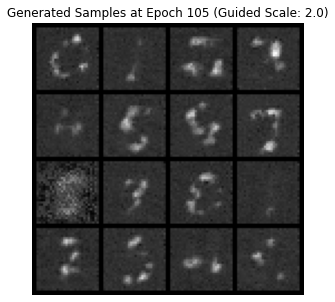

Epoch [120/1000], Average Training Loss: 0.0739


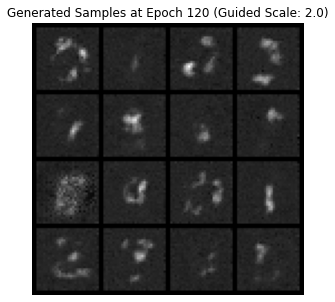

Epoch [135/1000], Average Training Loss: 0.0750


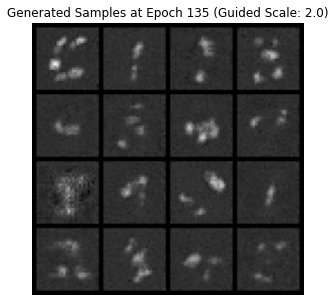

Epoch [150/1000], Average Training Loss: 0.0671


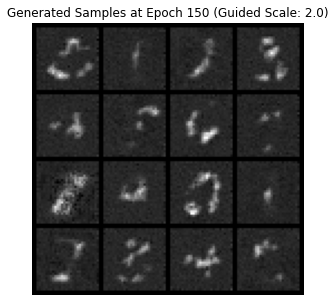

Epoch [165/1000], Average Training Loss: 0.0856


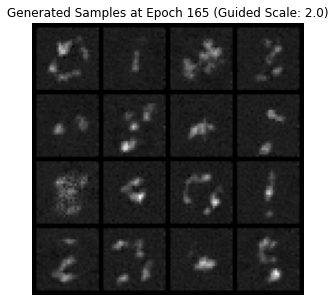

Epoch [180/1000], Average Training Loss: 0.0729


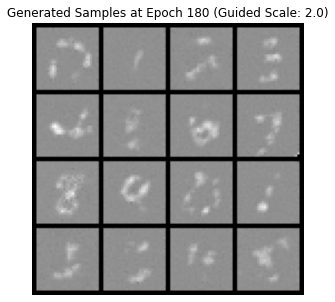

Epoch [195/1000], Average Training Loss: 0.0773


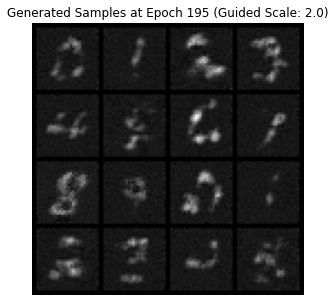

Epoch [210/1000], Average Training Loss: 0.0675


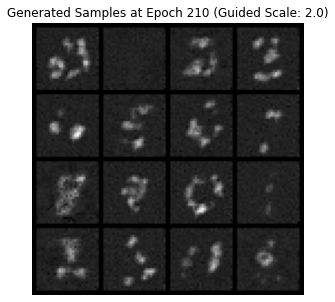

Epoch [225/1000], Average Training Loss: 0.0619


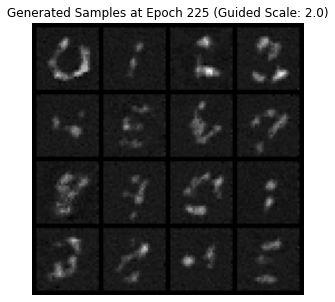

Epoch [240/1000], Average Training Loss: 0.0783


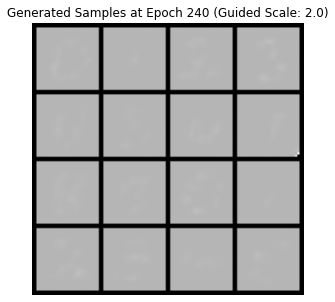

Epoch [255/1000], Average Training Loss: 0.0700


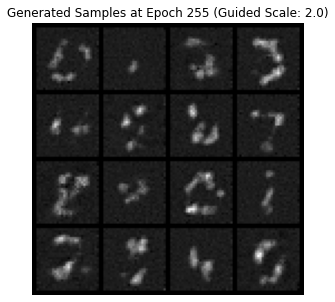

Epoch [270/1000], Average Training Loss: 0.0753


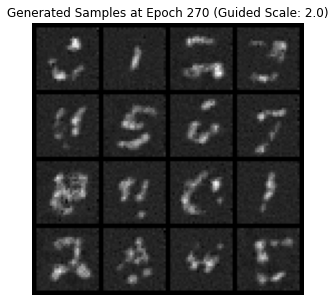

Epoch [285/1000], Average Training Loss: 0.0737


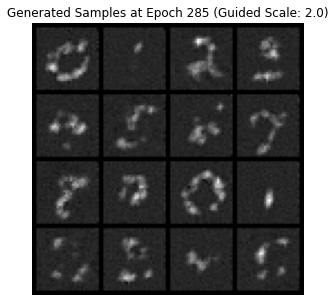

Epoch [300/1000], Average Training Loss: 0.0692


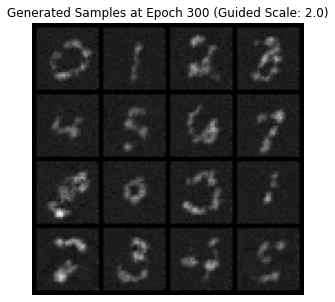

Epoch [315/1000], Average Training Loss: 0.0744


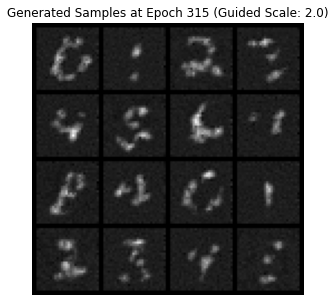

Epoch [330/1000], Average Training Loss: 0.0701


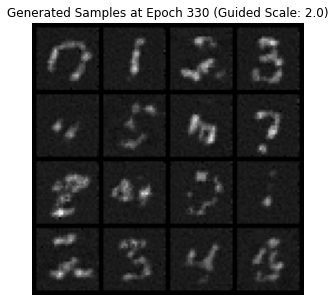

Epoch [345/1000], Average Training Loss: 0.0777


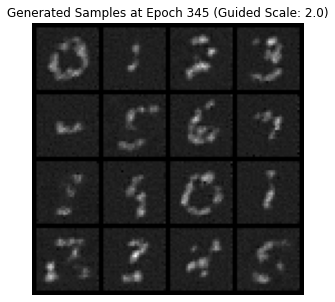

Epoch [360/1000], Average Training Loss: 0.0752


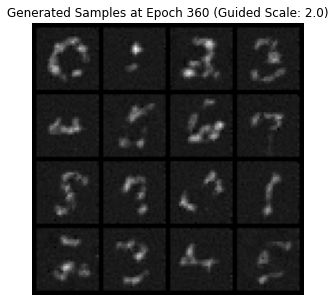

Epoch [375/1000], Average Training Loss: 0.0689


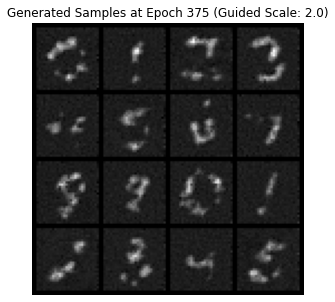

Epoch [390/1000], Average Training Loss: 0.0688


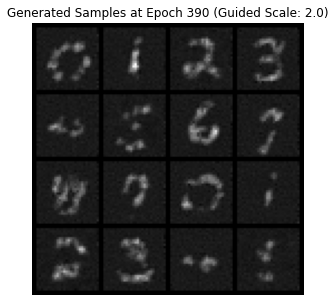

Epoch [405/1000], Average Training Loss: 0.0694


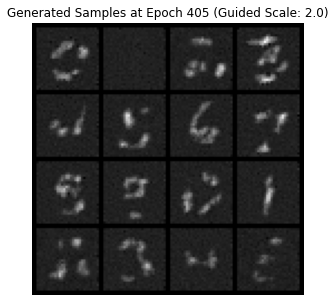

Epoch [420/1000], Average Training Loss: 0.0711


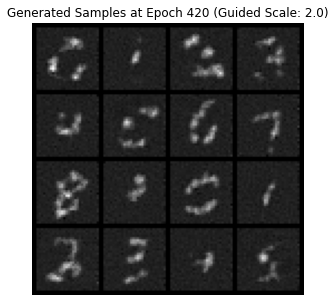

Epoch [435/1000], Average Training Loss: 0.0813


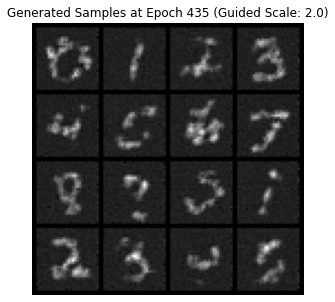

Epoch [450/1000], Average Training Loss: 0.0747


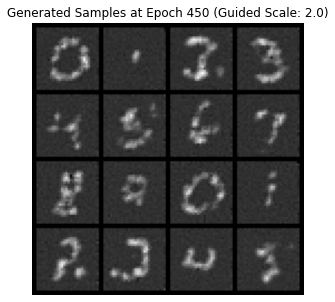

Epoch [465/1000], Average Training Loss: 0.0801


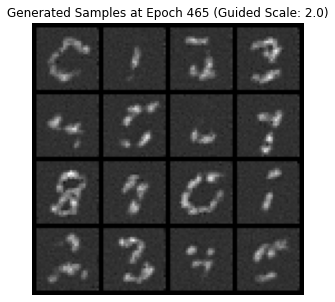

Epoch [480/1000], Average Training Loss: 0.0730


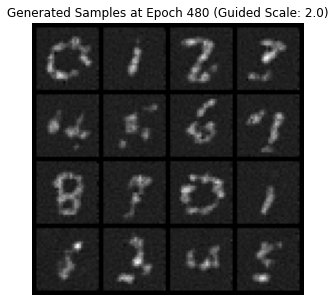

Epoch [495/1000], Average Training Loss: 0.0638


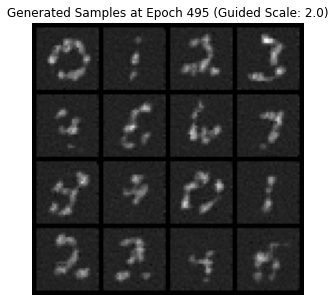

Epoch [510/1000], Average Training Loss: 0.0753


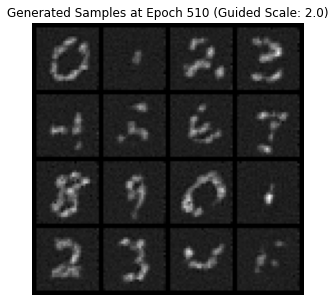

Epoch [525/1000], Average Training Loss: 0.0717


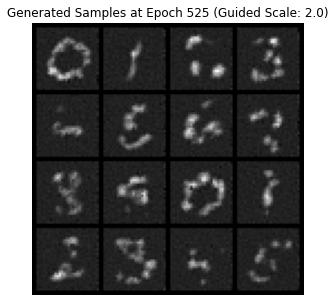

Epoch [540/1000], Average Training Loss: 0.0625


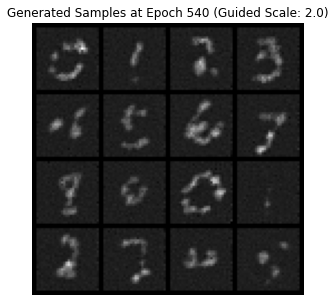

Epoch [555/1000], Average Training Loss: 0.0645


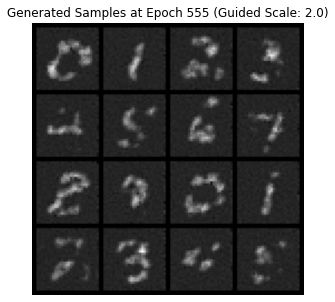

Epoch [570/1000], Average Training Loss: 0.0719


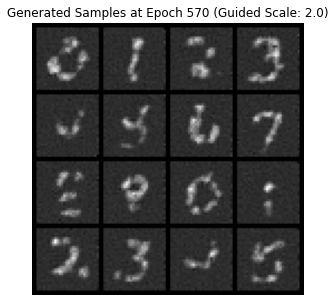

Epoch [585/1000], Average Training Loss: 0.0704


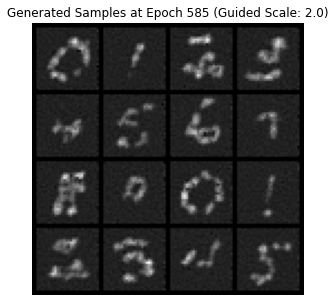

Epoch [600/1000], Average Training Loss: 0.0738


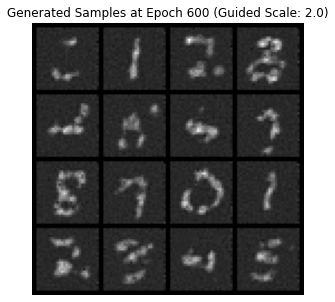

Epoch [615/1000], Average Training Loss: 0.0696


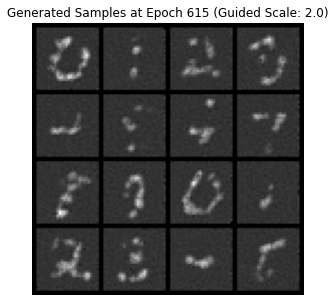

Epoch [630/1000], Average Training Loss: 0.0765


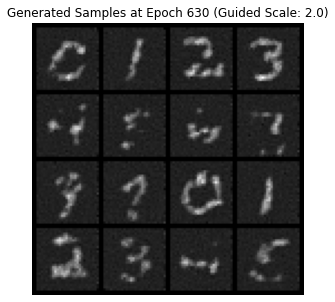

Epoch [645/1000], Average Training Loss: 0.0828


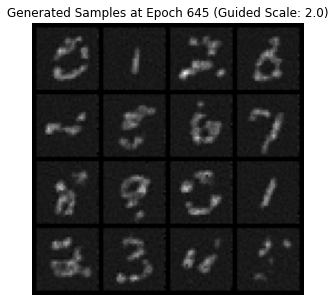

Epoch [660/1000], Average Training Loss: 0.0679


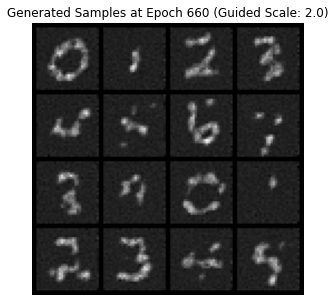

Epoch [675/1000], Average Training Loss: 0.0702


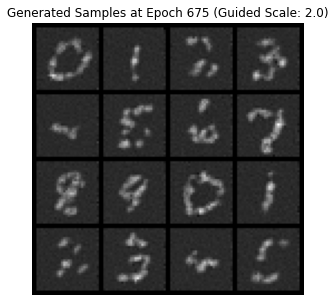

Epoch [690/1000], Average Training Loss: 0.0659


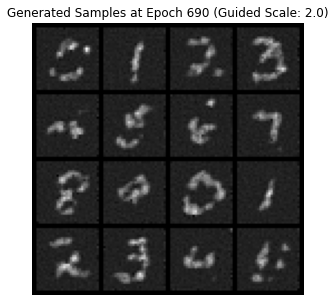

Epoch [705/1000], Average Training Loss: 0.0619


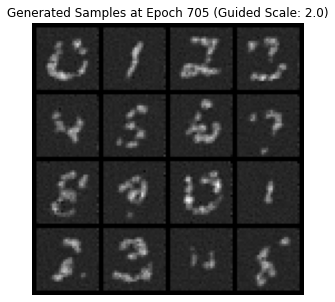

Epoch [720/1000], Average Training Loss: 0.0698


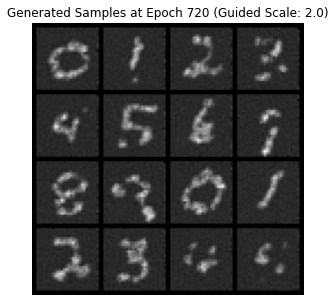

Epoch [735/1000], Average Training Loss: 0.0719


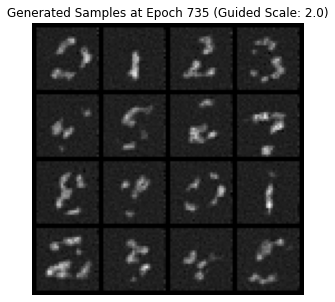

Epoch [750/1000], Average Training Loss: 0.0713


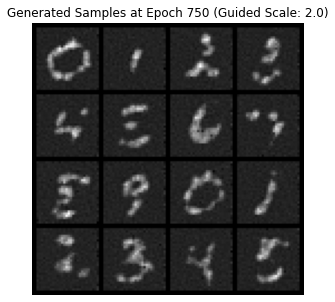

Epoch [765/1000], Average Training Loss: 0.0626


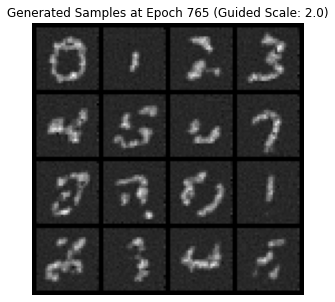

Epoch [780/1000], Average Training Loss: 0.0628


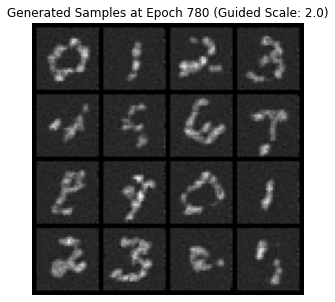

Epoch [795/1000], Average Training Loss: 0.0660


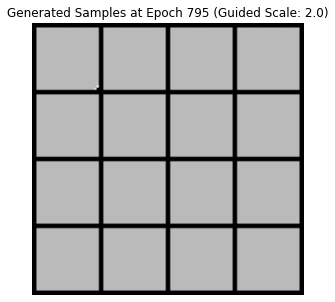

Epoch [810/1000], Average Training Loss: 0.0717


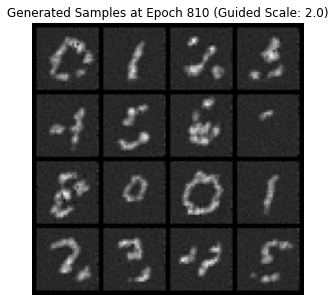

Epoch [825/1000], Average Training Loss: 0.0654


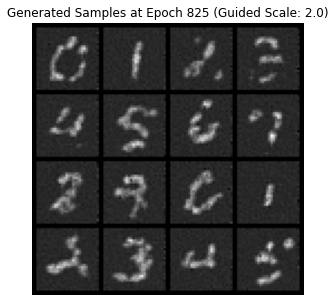

Epoch [840/1000], Average Training Loss: 0.0540


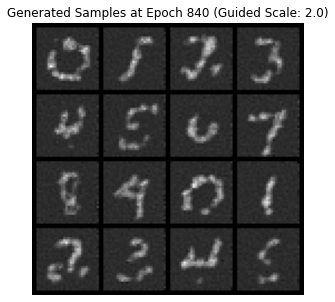

Epoch [855/1000], Average Training Loss: 0.0732


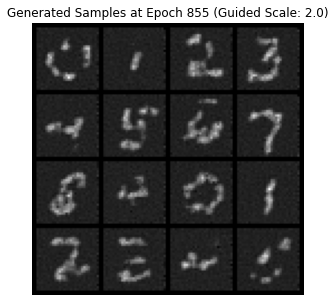

Epoch [870/1000], Average Training Loss: 0.0703


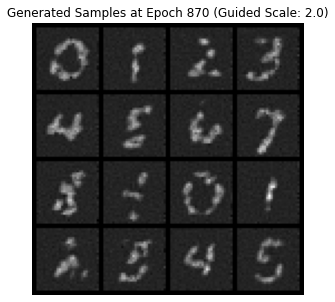

Epoch [885/1000], Average Training Loss: 0.0573


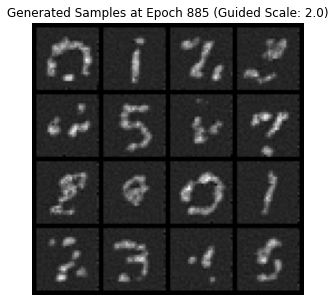

Epoch [900/1000], Average Training Loss: 0.0652


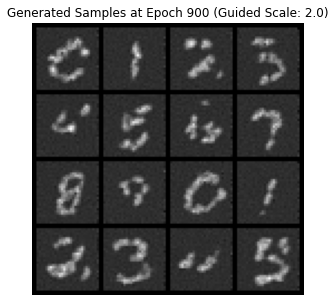

Epoch [915/1000], Average Training Loss: 0.0610


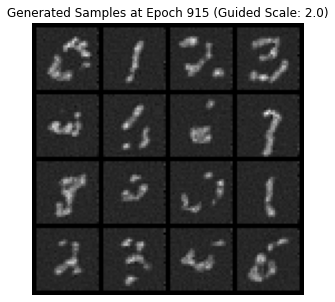

Epoch [930/1000], Average Training Loss: 0.0634


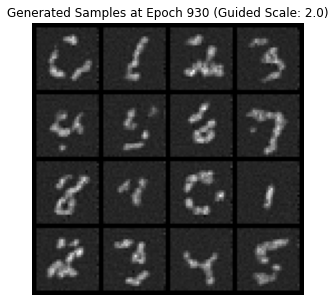

Epoch [945/1000], Average Training Loss: 0.0780


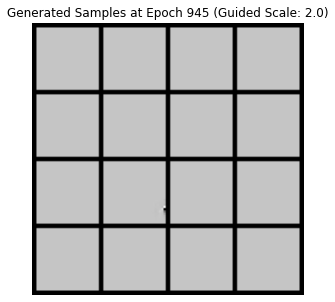

Epoch [960/1000], Average Training Loss: 0.0658


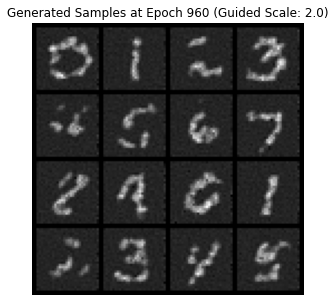

Epoch [975/1000], Average Training Loss: 0.0703


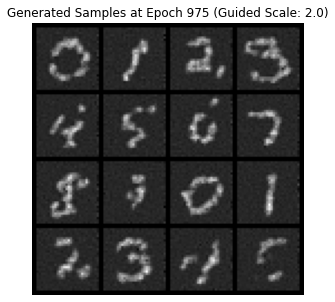

Epoch [990/1000], Average Training Loss: 0.0655


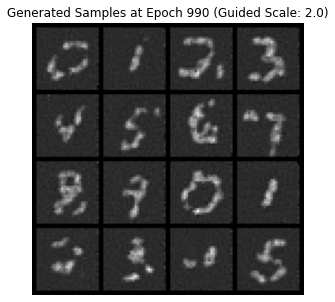

Classifier-free guided diffusion model saved to unet_mnist_diffusion_cfg.pth


In [9]:
p_unconditional = 0.1  # Probability for classifier-free guidance training
epochs_cfg = 1000 # Renaming to avoid conflict if 'epochs' is defined elsewhere with different value
learning_rate_cfg = 0.001 # Assuming learning_rate is defined, or define here

# Re-initialize optimizer if learning rate was changed, or ensure it uses the correct one
# optimizer = torch.optim.Adam(diff_model.parameters(), lr=learning_rate_cfg) 

for epoch in range(0, epochs_cfg):
    diff_model.train()
    
    # Example of LR scheduling, uncomment and adjust if needed
    # if epoch == int(epochs_cfg * 0.6): # e.g., at 60% of epochs
    #     for param_group in optimizer.param_groups:
    #         param_group['lr'] = learning_rate_cfg / 10

    epoch_loss = 0.0
    num_batches = 0
    for x_batch, labels_batch in trainloader:  # Ensure trainloader yields labels
        x_batch = x_batch.to(DEVICE)
        labels_batch = labels_batch.to(DEVICE)
        optimizer.zero_grad()
        
        # Using simpler t sampling from the other training loop for consistency
        t = torch.randint(0, total_timesteps, (x_batch.shape[0],), device=DEVICE)
        x_noisy_t, noise_truth = diff_forward.forward(x_batch, t)

        # Classifier-free guidance: randomly set labels to None for some batches/samples
        current_c = labels_batch
        if torch.rand(1).item() < p_unconditional:
            current_c = None  # U_Net's forward handles c=None for unconditional

        predicted_noise = diff_model(x_noisy_t, t.float(), c=current_c)
        loss = criterion(predicted_noise, noise_truth)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        num_batches += 1
        
    # Evaluation and visualization part
    if (epoch + 1) % 15 == 0:
        diff_model.eval() # Switch to eval mode for sampling
        avg_epoch_loss = epoch_loss / num_batches if num_batches > 0 else 0
        print(f"Epoch [{epoch+1}/{epochs_cfg}], Average Training Loss: {avg_epoch_loss:.4f}")
        with torch.no_grad():
            num_vis_samples = 16
            # Create target classes for visualization (e.g., 0,1,..,9,0,1,..)
            vis_target_classes = torch.arange(num_vis_samples, device=DEVICE) % 10 
            vis_guidance_scale = 2.0  # Example guidance scale for visualization
            samples, _ = sample_cfg_unconditional(diff_model, total_timesteps, diff_forward, DEVICE,
                                num_samples=num_vis_samples,
                                target_classes=vis_target_classes,
                                guidance_scale=vis_guidance_scale)

        grid = vutils.make_grid(samples, nrow=4, normalize=True, padding=2)
        plt.figure(figsize=(10, 5))
        plt.axis('off')
        plt.title(f"Generated Samples at Epoch {epoch+1} (Guided Scale: {vis_guidance_scale})")
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
        plt.show()
        # diff_model.train() # Already handled by the start of the next epoch loop

model_save_path_cfg = "unet_mnist_diffusion_cfg.pth" # New name for the guided model
torch.save(diff_model.state_dict(), model_save_path_cfg)
print(f"Classifier-free guided diffusion model saved to {model_save_path_cfg}")

## Evaluation

In [ ]:

class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5, padding=2)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(400, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)   

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 400)
        x = F.relu(self.fc1(x))
        features = F.relu(self.fc2(x))  #m by 84
        x = self.fc3(features)
        return x, features

In [ ]:
model_lenet = LeNet()
model_lenet.to(DEVICE)
epochs=20
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_lenet.parameters(),lr=0.001,momentum=0.9)


for epoch in range(epochs):
    for i, data in enumerate(trainloader):
        inputs,labels=data
        inputs,labels= inputs.to(DEVICE) , labels.to(DEVICE)
        optimizer.zero_grad()
        outputs, _ =model_lenet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer .step()
    print(f'Epoch {epoch+1} completed')




Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed


In [ ]:
model_lenet.eval()
correct = 0
total = 0

with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs, _=model_lenet(images)
        _, predicted=torch.max(outputs.data, 1)
        total+=labels.size(0)
        correct+=(predicted == labels).sum().item()

accuracy=100*correct/total
print(accuracy)


98.73


In [ ]:

features = []

with torch.no_grad():
    for data in testloader:
        images, _= data  
        images =images.to(DEVICE)
        _, batch_features = model_lenet(images)
        features.append(batch_features.cpu().numpy())

features_groundTruth = np.concatenate(features, axis=0)




In [ ]:
def sample(diff_model, classifier_model, total_timesteps, diff_forward, device, target_classes, guidance_scale, num_samples=16, batch_size=64):
    diff_model.eval()
    classifier_model.eval()  # Ensure classifier is in eval mode
    alphas = diff_forward.alphas.to(device)
    alpha_bars = diff_forward.alpha_bars.to(device)
    all_samples = []
    intermediate_samples_batches = [] # To store intermediate samples from all batches
    steps_to_save = [int(i) for i in np.linspace(0, total_timesteps - 1, num=8)] # Define steps to save intermediates

    if target_classes.shape[0] != num_samples:
        raise ValueError(f"target_classes length ({target_classes.shape[0]}) must match num_samples ({num_samples})")
    target_classes = target_classes.to(device)

    for i in range(0, num_samples, batch_size):
        current_batch_size = min(batch_size, num_samples - i)
        x_t = torch.randn(current_batch_size, 1, 28, 28, device=device)
        current_target_classes_batch = target_classes[i : i + current_batch_size]
        batch_intermediate_samples = [] # Intermediates for the current batch

        for t_scalar in reversed(range(total_timesteps)):  # t_scalar is Python int
            t_tensor = torch.full((current_batch_size,), t_scalar, device=device, dtype=torch.long)
            
            # Perform operations requiring gradients in a separate block or ensure no_grad is temporarily disabled
            with torch.enable_grad(): # Temporarily enable gradients for this block
                x_t_for_grad = x_t.detach().clone() # Clone and detach for grad calculation
                x_t_for_grad.requires_grad_(True)
            
                logits, _ = classifier_model(x_t_for_grad)
                log_probs = F.log_softmax(logits, dim=-1)
                selected_log_probs = log_probs[torch.arange(current_batch_size), current_target_classes_batch]
                cond_grad = torch.autograd.grad(selected_log_probs.sum(), x_t_for_grad)[0]

            # U-Net prediction (unconditional) - ensure this is outside grad computation or uses x_t.detach() if x_t had grad
            # The outer loop for sampling should ideally be under torch.no_grad() for efficiency,
            # with specific parts enabling grad as shown above.
            with torch.no_grad(): # Ensure U-Net prediction and sampling step are no_grad
                unconditional_epsilon = diff_model(x_t, t_tensor) # Original x_t
    
                # Combine with guidance
                sqrt_one_minus_alpha_bar_t = torch.sqrt(1. - alpha_bars[t_scalar]) # scalar
                predicted_noise = unconditional_epsilon - guidance_scale * sqrt_one_minus_alpha_bar_t * cond_grad
    
                # Standard DDPM reverse step:
                alpha_t = alphas[t_scalar]
                alpha_bar_t = alpha_bars[t_scalar] # Not used in this formulation of sigma_t
                
                mean_coeff = (1 - alpha_t) / torch.sqrt(1 - alpha_bar_t) # alpha_bar_t is used here
                mean = (1 / torch.sqrt(alpha_t)) * (x_t - mean_coeff * predicted_noise)
                
                if t_scalar > 0:
                    sigma_t = torch.sqrt(1 - alpha_t) # beta_t = 1 - alpha_t
                    noise_z = torch.randn_like(x_t)
                    x_t = mean + sigma_t * noise_z
                else:
                    x_t = mean  # At t=0, no noise is added

            if t_scalar in steps_to_save:
                batch_intermediate_samples.append(x_t.cpu().detach().clone())

        with torch.no_grad(): # Ensure appending to list is also no_grad
            all_samples.append(x_t.cpu().detach())
            # Reverse the collected intermediates for this batch to be in chronological order (t=T -> t=0)
            intermediate_samples_batches.append(list(reversed(batch_intermediate_samples)))
            if device == torch.device("cuda"):
                torch.cuda.empty_cache()
        
    all_samples_tensor = torch.cat(all_samples, dim=0)
    
    # Consolidate intermediate samples across batches
    # Assuming all batches went through the same number of save steps
    num_saved_steps = len(steps_to_save)
    final_intermediate_samples = [torch.cat([intermediate_samples_batches[b_idx][step_idx] for b_idx in range(len(intermediate_samples_batches))], dim=0) for step_idx in range(num_saved_steps)]
    
    return all_samples_tensor.numpy(), final_intermediate_samples

In [ ]:
# Load the unconditionally trained U-Net model
unconditional_unet_path = "unet_diff_mnist.pth" # Path to your unconditionally trained U-Net model
unconditional_unet = U_net(code_dim=128, num_classes=None, time_embedding_dim=64).to(DEVICE) # num_classes=None for unconditional model
unconditional_unet.load_state_dict(torch.load(unconditional_unet_path))
unconditional_unet.eval()
print(f"Unconditionally trained U-Net loaded from {unconditional_unet_path}")

# Ensure LeNet classifier is in eval mode (assuming model_lenet is already trained and available)
if 'model_lenet' in globals():
    model_lenet.eval()
    print("LeNet classifier is in evaluation mode.")
else:
    print("Error: LeNet classifier (model_lenet) not found. Please train or load it first.")

# Parameters for classifier-guided sampling
guided_total_timesteps = 2000 # Should match the training of unconditional_unet
guided_diff_forward = DiffForward(total_timesteps=guided_total_timesteps)

# For FID evaluation
num_samples_fid_guided = 1000
guidance_scale_fid = 2.0 # Example guidance scale, adjust as needed
# Create target classes for FID: e.g., 100 samples for each class (0-9)
target_classes_fid = torch.arange(10).repeat_interleave(num_samples_fid_guided // 10).to(DEVICE)
if len(target_classes_fid) < num_samples_fid_guided: # Handle cases where num_samples_fid is not perfectly divisible by 10
    target_classes_fid = torch.cat([target_classes_fid, torch.arange(num_samples_fid_guided - len(target_classes_fid)).to(DEVICE) % 10])

# For visualization
num_samples_vis_guided = 24
guidance_scale_vis = 3.0 # Example guidance scale for visualization
# Create target classes for visualization (e.g., specific digits or a sequence)
target_classes_vis = (torch.arange(num_samples_vis_guided) % 10).to(DEVICE) # Generates 0,1,2,3,4,5,6,7,8,9,0,1,...

In [ ]:
# Generate samples for FID using classifier guidance
print(f"Generating {num_samples_fid_guided} samples for FID with guidance scale {guidance_scale_fid}...")
gen_fid_guided, _ = sample(
    diff_model=unconditional_unet, # Use the unconditionally trained U-Net
    classifier_model=model_lenet, # Use the LeNet classifier
    total_timesteps=guided_total_timesteps,
    diff_forward=guided_diff_forward,
    device=DEVICE,
    target_classes=target_classes_fid, # Target classes for FID
    guidance_scale=guidance_scale_fid, # Guidance scale for FID
    num_samples=num_samples_fid_guided,
    batch_size=64 # Adjust batch size as needed based on GPU memory
)
print("FID sample generation complete.")

In [ ]:
# Ensure gen_fid_guided is a PyTorch tensor before passing to model_lenet
if isinstance(gen_fid_guided, np.ndarray):
    gen_fid_guided_tensor = torch.tensor(gen_fid_guided).to(DEVICE)
else:
    gen_fid_guided_tensor = gen_fid_guided.to(DEVICE) # Assuming it might already be a tensor

# Add channel dimension if missing (e.g., if shape is [N, H, W] instead of [N, C, H, W])
if gen_fid_guided_tensor.ndim == 3:
    gen_fid_guided_tensor = gen_fid_guided_tensor.unsqueeze(1)

_, features_dif_guided = model_lenet(gen_fid_guided_tensor)
features_dif_guided = features_dif_guided.detach().cpu().numpy()
print(f"Shape of extracted features from guided samples: {features_dif_guided.shape}")

In [ ]:
def calculate_fid(real_features, gen_features):
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = gen_features.mean(axis=0), np.cov(gen_features, rowvar=False)
    ssdiff = np.sum((mu1 - mu2) ** 2.0)
    # For a robust FID, you'd also include the trace of the square root of the product of covariance matrices:
    # from scipy.linalg import sqrtm
    # covmean = sqrtm(sigma1.dot(sigma2))
    # if np.iscomplexobj(covmean):
    #     covmean = covmean.real
    # fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    # Simplified FID for this context (just squared difference of means)
    fid = ssdiff 
    return fid

# Calculate FID for classifier-guided samples
fid_guided = calculate_fid(features_groundTruth, features_dif_guided)
print(f"FID (guided samples vs ground truth): {fid_guided}")

# If you still have features_dif (from unconditional or CFG samples) and want to compare:
# if 'features_dif' in globals():
#     fid_unconditional_or_cfg = calculate_fid(features_groundTruth, features_dif)
#     print(f"FID (original generated vs ground truth): {fid_unconditional_or_cfg}")

98.93422

In [ ]:
# This cell previously had gen.shape. 
# 'gen' might refer to samples from an older, unconditional/CFG run.
# For classifier-guided samples used in FID, the variable is gen_fid_guided.
if 'gen_fid_guided' in globals():
    print(f"Shape of classifier-guided samples for FID: {gen_fid_guided.shape}")
else:
    print("gen_fid_guided not found. Run the guided sampling cell for FID first.")

# For samples generated for visualization with guidance:
if 'final_samples_guided' in globals():
    print(f"Shape of classifier-guided samples for visualization: {final_samples_guided.shape}")
else:
    print("final_samples_guided not found. Run the guided sampling cell for visualization first.")

(1000, 1, 28, 28)

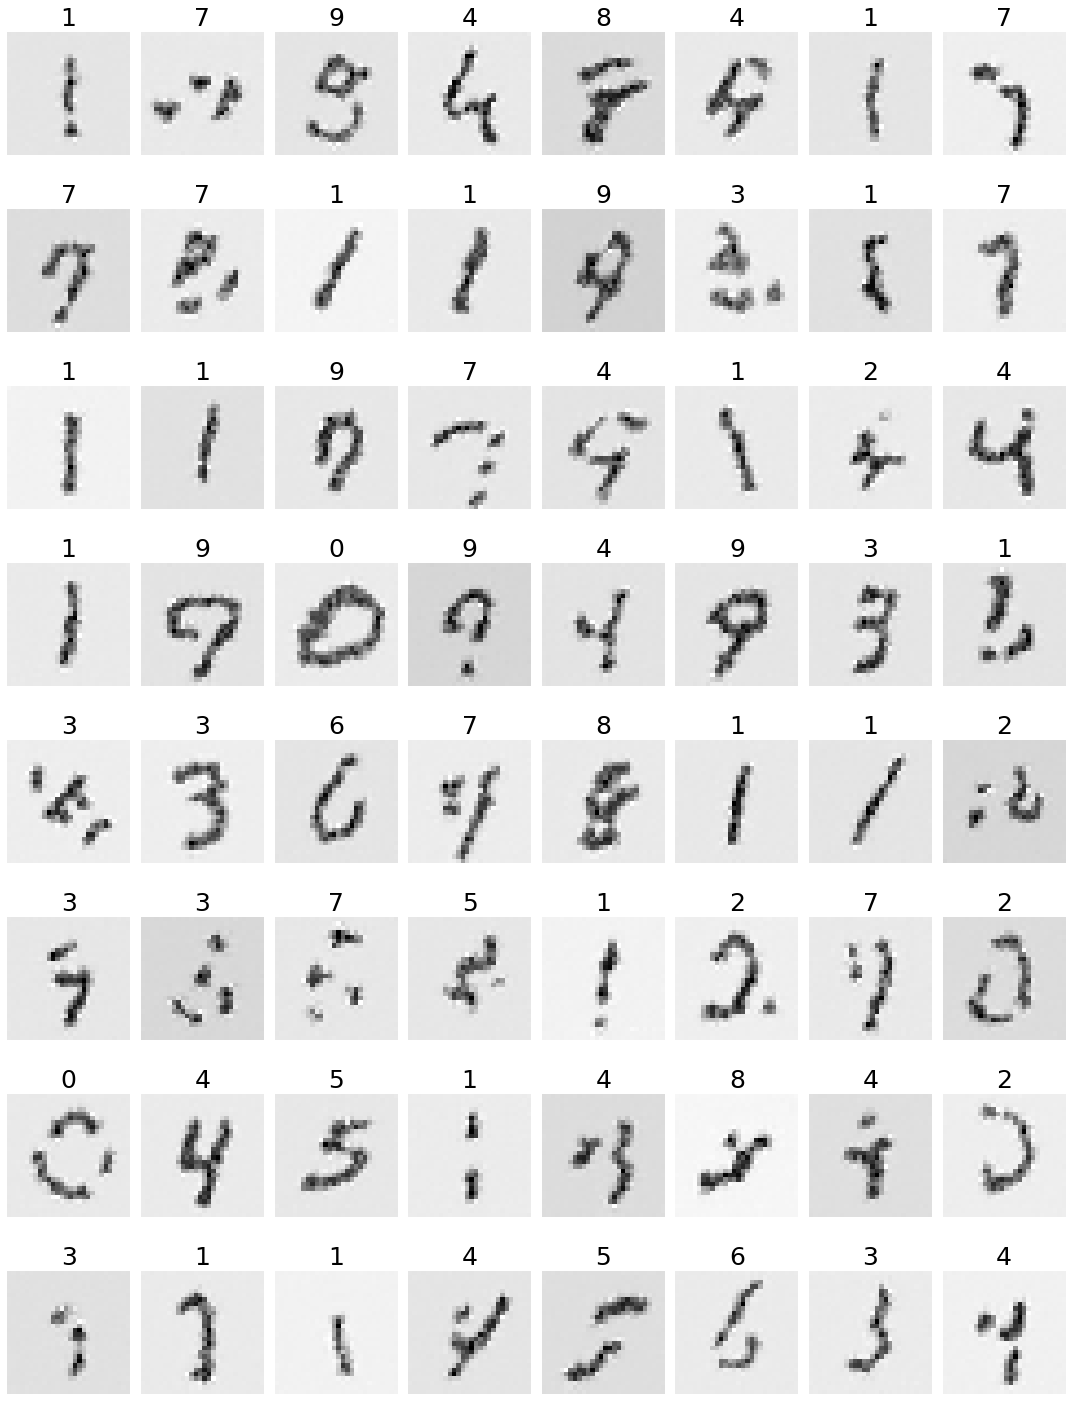

In [ ]:
# Visualize some of the classifier-guided samples (e.g., from the FID batch or visualization batch)
# Using final_samples_guided from the visualization cell as it's likely smaller and has target classes defined for display.
if 'final_samples_guided' in globals() and 'target_classes_vis' in globals():
    samples_to_plot = final_samples_guided 
    # Convert to tensor, ensure on DEVICE, and add channel dim if needed for LeNet
    samples_to_plot_tensor = torch.tensor(samples_to_plot).to(DEVICE)
    if samples_to_plot_tensor.ndim == 3:
        samples_to_plot_tensor = samples_to_plot_tensor.unsqueeze(1)

    # Get predictions from LeNet for these samples
    with torch.no_grad():
        prediction_viz, _ = model_lenet(samples_to_plot_tensor)
        pred_class_viz = torch.argmax(prediction_viz, dim=1)

    num_to_display = min(64, samples_to_plot.shape[0]) # Display up to 64 samples
    grid_size = int(np.ceil(np.sqrt(num_to_display)))
    
    figure = plt.figure(figsize=(15, 15)) # Adjusted figure size
    plt.suptitle(f"Classifier-Guided Samples (Guidance: {guidance_scale_vis}) - LeNet Predictions", fontsize=16)
    for index in range(num_to_display):
        plt.subplot(grid_size, grid_size, index + 1)
        plt.axis('off')
        # Title: LeNet Prediction (Target Class)
        plt.title(f"Pred: {pred_class_viz[index].item()} (Tgt: {target_classes_vis[index].item()})", fontsize=10)
        plt.imshow(samples_to_plot[index].squeeze(), cmap='gray_r')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("final_samples_guided or target_classes_vis not found. Run the guided sampling for visualization cell first.")

Text(0.5, 1.0, 'Distribution of Predicted Classes')

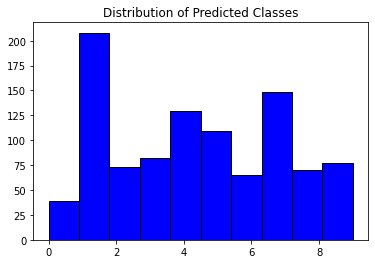

In [ ]:
# Plot distribution of LeNet's predictions on the classifier-guided samples (from visualization batch)
if 'pred_class_viz' in globals():
    plt.hist(pred_class_viz.cpu().numpy(), bins=np.arange(11)-0.5, edgecolor='black', color='green', rwidth=0.8)
    plt.xticks(range(10))
    plt.xlabel("Predicted Class by LeNet")
    plt.ylabel("Frequency")
    plt.title(f'Distribution of LeNet Predictions on Classifier-Guided Samples (Scale: {guidance_scale_vis})')
    plt.show()
else:
    print("pred_class_viz not found. Run the preceding cell to generate predictions first.")